# Titanic 1: Creating a Heuristic Model

**Challenge overview:**

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).


**Dataset variables:**

*   survival -->	Whether a passenger survived or not
*   pclass -->	Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
*   sex -->	Sex
*   Age -->	Age in years
*   sibsp -->	# of siblings / spouses aboard the Titanic
*   parch -->	# of parents / children aboard the Titanic
*   ticket -->	Ticket number
*   fare -->	Passenger fare
*   cabin -->	Cabin number
*   embarked -->	Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

## Baseline Modelling:
While we do have clear performance metrics with SML like accuracy, what a "good score" looks like is different for different tasks. 90% accuracy might be good for something extremely difficult, but the same score would be much less impressive with an easy task. In order to interpret how "good" our model's score is, we'll need some baseline that measures the difficulty of the task. There are two common approaches to this:
1. **Dummy Modelling:** Dummy models are extremely simple estimators that simply predict the most common class in the training data (or the average target value for regression tasks). For instance, if there are more inexpensive houses than expensive ones in the training data, a dummy model will simply predict "inexpensive" for all houses. Dummy models do not make use of the predictor features at all. We shouldn't be impressed when our actual SML model gets 90% accuracy if 90% of the data is the same class, and dummy models help highlight that for us.
2. **Rule-Based Baseline:** Another thing we can do is try to write our own very simple program based on domain knowledge and a bit of data exploration. These programs are often referred to as "Heuristic Models." They take more time than dummy models but we can also learn more about the dataset and the problem the model is trying to solve which may help us to design our ML pipeline and interpret the final results. It may also be that the heuristic model performs sufficiently well that machine learning isn't actually necessary for the task.

In this notebook we will establish a baseline with the titanic dataset using dummy modelling and heuristic modelling and then it will be your job to do the same with the housing data.

## 1. Data Reading & First Glance

In [29]:
import pandas as pd

url = "https://drive.google.com/file/d/1g3uhw_y3tboRm2eYDPfUzXXsw8IOYDCy/view?usp=sharing"
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]

data = pd.read_csv(path)
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

The target column (what we want our model to predict) is usually denoted as `y` and we call it a `label`. We will "pop" it out from the rest of the data:

In [30]:
y = data.pop("Survived")

As you can see, the target is just a bunch of zeros and ones. 1 means the passenger survived and 0 means they did not survive:

In [31]:
print(y.tolist())

[0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 

The "feature vector" (the columns used to predict the target) is denoted as `X`.

Some of the columns in the original dataset are unique identifiers of each passenger. Unique identifiers are not useful when it comes to finding patterns in the data. So, the first step when building our `X`, the vector of predictor features, is to drop them:

In [32]:
X = data.drop(columns=["PassengerId", "Name", "Ticket"])
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S


Even if the target (`y`) and the features (`X`) are in two different objects, there is still a very easy mapping between them: the first row in `X` and the first element in `y` both correspond to the first passenger, the second row in `X`and the second element in `y` correspond to the second passenger, and so on.

## 2. Train-Test Split

Before exploring the data, we will split the dataset into 2 chunks: train and test. We will use the train set to find patterns in the data and create a model. The test set will remain untouched, unseen, unexplored. It will be the "reality check" for our model, it will let us know whether our model is able to generalize.

Here, we're using the function `train_test_split` to shuffle the observations randomly and create the train and test sets for both the `X` and the `y` objects at the same time, ensuring that they are shuffled the same way:

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=31416)

In [34]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
477,3,male,29.0,1,0,7.0458,NaN,S
504,1,female,16.0,0,0,86.5000,B79,S
744,3,male,31.0,0,0,7.9250,NaN,S
473,2,female,23.0,0,0,13.7917,D,C
429,3,male,32.0,0,0,8.0500,E10,S


In [35]:
y_train.head()

,Survived
477,0
504,1
744,1
473,1
429,1


As you can see from the indices, both the `X` and `y` train sets contain first the passenger in position `477`, then the one in position `504`, etc.

The same applies for the test set:

In [36]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
36,3,male,NaN,0,0,7.2292,NaN,C
716,1,female,38.0,0,0,227.5250,C45,C
131,3,male,20.0,0,0,7.0500,NaN,S
507,1,male,NaN,0,0,26.5500,NaN,S
13,3,male,39.0,1,5,31.2750,NaN,S


In [37]:
y_test.head()

,Survived
36,1
716,1
131,0
507,1
13,0


## 3. Data Exploration

When you have a deeper understanding of machine learning, data exploration can help you determine what tools best suit your problem. For now, it will help us build our rule-based baseline by giving us a preliminary understanding of the dataset.

We may also want to look at the distribution of the target feature and its relationships with the predictor features. That will require that we recombine the X and y columns of our training data.

In [38]:
train_data = X_train.copy()
train_data['Survived'] = y_train

In [39]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 477 to 838
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    object 
 2   Age       568 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Cabin     164 non-null    object 
 7   Embarked  710 non-null    object 
 8   Survived  712 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 55.6+ KB


In [40]:
train_data.isna().sum()

,0
Pclass,0
Sex,0
Age,144
SibSp,0
Parch,0
Fare,0
Cabin,548
Embarked,2
Survived,0


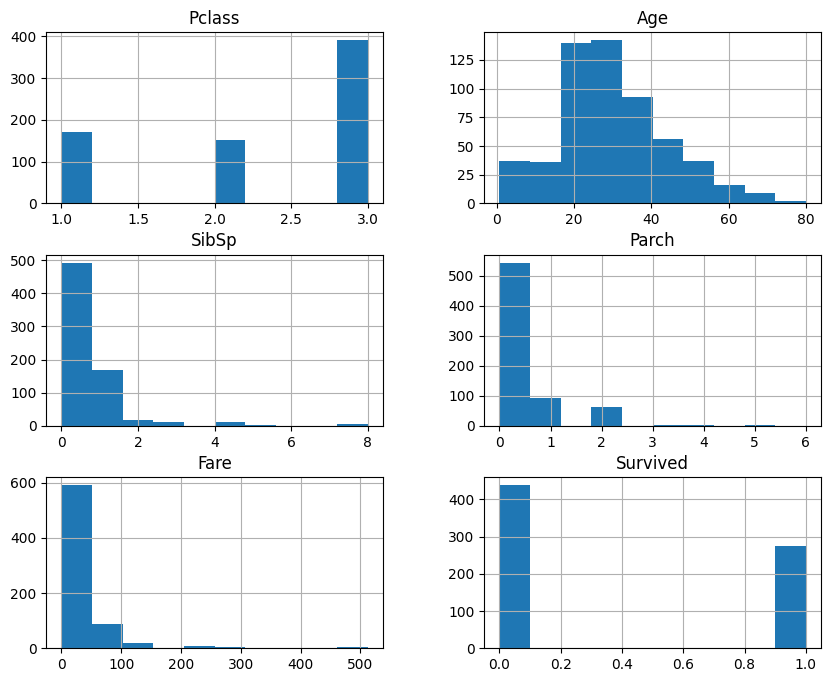

In [41]:
train_data.hist(figsize=(10, 8));

We'll leave it to you to explore the data further. One thing that might help your rule-based baseline is if you look at how correlated each predictor feature is with the target feature.<br><br>

(Tip: The library [ydata-profiling](https://docs.profiling.ydata.ai/latest/) can be a very helpful shortcut for quick data exploration. Just run the following code:
```
!pip install ydata-profiling
from ydata_profiling import ProfileReport
ProfileReport(train_data)
```
This will give you detailed summary statistics on all of the features as well as a correlation matrix at the bottom of the report)

## 4. Iteration 0 - Baseline Modelling

We've seen that a huge advantage that supervised machine learning has over unsupervised is the ability to score the model. But even if I can say my model has 90% accuracy, how good that is depends on how difficult the problem is. If 90% of the passengers had died, I could get that high of a score very easily by just predicting that all the passengers died. In contrast, there may be other problems that are extremely complex where getting 90% accuracy would be very difficult and very impressive.<br><br>
In order to know what a good score looks like for our problem, we need to set a baseline. There are two common methods for this:<br><br>
**1. Dummy Models:**<br>
Dummy models make their predictions based entirely on the distribution of the target feature in the training data. In a classification task, that means predicting the most frequent class. In our case, that means predicting that every passenger died. We call these "dummy" models because they are like crash-test-dummies.<br><br>
**2. Heuristic Models:**<br>
Unlike dummy models, heuristic models can take advantage of the predictor features. In this case you have to come up with some simple rules for predicting the target feature based on what you know from domain knowlege and data exploration. For instance, we might predict that all the third-class passengers died while everyone else survived based on what we can see in the training data. This is a very simple rule but it will set a better baseline than the dummy model because it can capture if there are any simple patterns that are highly predictive.<br><br>
In practice, our choice between dummy models and heuristic models often comes down to time constraints. Dummy models are very quick so they can be a good method for setting a baseline without much thought or effort.<br><br>
Setting a baseline doesn't just help us evaluate the model, it also helps us evaluate whether machine-learning is necessary in the first place. Machine learning models shouldn't be the first option to solve every problem. Machine learning adds complexity to a business, and it should only be implemented if it represents a clear advantage compared to a simple working solution that the company can build following simple rules, common sense, or gained expertise.

Let's start by checking which class is most common in the training data as this is what our dummy model with predict for everything

In [42]:
y_train.value_counts()

,count
Survived,
0,438
1,274


It looks like more passengers died than survived. That means our dummy model will just predict "died" for all passengers.

Now let's create our dummy model. Sklearn has a `DummyClassifier` which acts a lot like a real machine learning model, but of course all it is "learning" is what class is most common in the data we fit it to.

In [43]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier()

# All SML models require both the features (X) and the labels (y) when fitting
# The DummyClassifier mimics this structure even though it doesn't end up using X at all
dummy_model.fit(X_train, y_train)

DummyClassifier()

We will see this same method `.predict` with real SML models as well. To make predictions with a fit model, we simply provide predictor features (X) and the model will return a series of predictions of the target (y).

In [44]:
dummy_train_pred = dummy_model.predict(X_train)

In this case, these predictions should just be a series of 0s because it is predicting that every passenger died.

In [45]:
dummy_train_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

How good are those predictions? We can compare them with the true values and find out the percentage of correctly predicted passengers. This metric is called **accuracy**:

In [46]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_true = y_train,
                                y_pred = dummy_train_pred)

round(train_accuracy, 2)

0.62

Okay, we have about a 62% accuracy in our train set. Let's find out how would have it done in our test set:

In [47]:
dummy_test_pred = dummy_model.predict(X_test)

test_accuracy = accuracy_score(y_true = y_test,
                               y_pred = dummy_test_pred)

round(test_accuracy, 2)

0.62

The performance is pretty much the same. This is typical from simple models: they have a low performance, but the performance stays the same in the data where they were trained and in new data.

A model with a consistent performance between the training and testing set is said to have a **low variance**, which is good. This means the patterns it captures are population-wide patterns that aren't dependent on which observations are randomly sampled from that population. <br>However, low variance often comes at the cost of **high bias**. Bias means systematic mistakes in the models predictions. Patterns in the model's mistakes are equivalent to predictive patterns the model has missed by being too simple (e.g. it keeps misclassifying female third-class passengers as having died because it's missed out on the role sex played in the evacuation process).<br> The more complex we make our model, the more nuanced of patterns it can detect, lowering the bias; but this often results in the model capturing patterns in the particular sample it was fit to that don't generalize to the whole population (what we call "**noise**") which increases the variance. This problem is the central dilemma of supervised machine learning and it goes by the name of **"The Bias-Variance Tradeoff"**

Our model, with high bias, is missing important connections between the features and the target. Another term to describe this is **underfitting**.


Ideally, we want low variance and low bias: a high accuracy consistent across the train and the test set.

https://www.bmc.com/blogs/bias-variance-machine-learning

## **Exercise 1**:

- Explore the training data and come up with a heuristic model. A possible guess, for example, would be that women survived and men died, since they were prioritized during evacuation. Write this as a python function that takes in X data and returns a series of predictions.
- Check the accuracy of your new model both in the train set and in the test set. Have you outperformed the dummy model?
- Remember the accuracy you got. This is the baseline you'll use to judge your machine learning model's performance against


# Step 1 — Create a Heuristic Model

## What it is

A heuristic model is a simple rule-based model based on intuition or domain knowledge.

In the Titanic dataset I know that:

Women were prioritized during evacuation.

So I create the rule:

female → survived (1)
male → died (0)

## Why I do this

I want a simple baseline model that is smarter than the dummy model.

The dummy model predicted everyone died, but this rule uses information from a feature (Sex).

## What this code does

I create an empty list called heuristic_train_pred

I loop through the Sex column

If the passenger is female → predict survived (1)

If the passenger is male → predict died (0)

The list becomes our predictions.

In [48]:
heuristic_train_pred = []

for sex in X_train["Sex"]:

    if sex == "female":
        heuristic_train_pred.append(1)

    else:
        heuristic_train_pred.append(0)

# Step 2 — Calculate Accuracy on the Training Set

## What it is

Accuracy measures how many predictions are correct.

Formula:

Accuracy = correct predictions / total predictions

## Why we do this

I want to know how good our heuristic model is.


## What this code does

accuracy_score compares:

true values → y_train

with

predicted values → heuristic_train_pred

It returns the percentage of correct predictions.

In [49]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(
    y_true = y_train,
    y_pred = heuristic_train_pred
)

round(train_accuracy, 2)

0.78

# Step 3 — Make Predictions on the Test Set

## What it is

The test set is new data the model has never seen.

## Why I do this

I check if the model generalizes to new data.

A good model should perform similarly on train and test data.



This applies the same rule to the test data.

In [50]:
heuristic_test_pred = []

for sex in X_test["Sex"]:

    if sex == "female":
        heuristic_test_pred.append(1)

    else:
        heuristic_test_pred.append(0)

# Step 4 — Calculate Test Accuracy


## What it does

It measures how well the heuristic model predicts survival in unseen data.

In [51]:
test_accuracy = accuracy_score(
    y_true = y_test,
    y_pred = heuristic_test_pred
)

round(test_accuracy, 2)

0.8

# Step 5 — Compare With the Dummy Model

## Dummy model accuracy:

≈ 0.62

## Heuristic model accuracy usually:

≈ 0.75 – 0.80

## Why this matters

It shows that:

Using feature information (Sex) improves predictions

Even a simple rule can outperform the dummy baseline.

# ** Interpretation

## The heuristic model performs better because it uses a meaningful feature (Sex), while the dummy model only predicts the majority class.

One way you could code this is with some simple pandas methods. Here is an example:
```
def heuristic_model(X):
    # Initially predict all passengers died
    X['Surived'] = 0
    # Come up with conditions that you think made people more likely to survive
    condition1 = X[feature] > threshold
    condition2 = X[feature] == category
    surv_filter = condition1 and condition2 # could also have "or" conditions
    # Change prediction to survived for just those passengers
    X.loc[surv_filter, 'Survived'] = 1
    # Pop and return the predictions
    preds = X.pop('Survived')
    return preds
```

# Another way:


In [52]:

# 1. heuristic
def heuristic_model(X):

    preds = []

    for sex in X["Sex"]:
        if sex == "female":
            preds.append(1)   # survived
        else:
            preds.append(0)   # died

    return preds


# 2. prediction on  train
heuristic_train_pred = heuristic_model(X_train)


# 3. calculate the accuracy
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, heuristic_train_pred)

round(train_accuracy,2)

# 4.on the test
heuristic_test_pred = heuristic_model(X_test)

test_accuracy = accuracy_score(y_test, heuristic_test_pred)

round(test_accuracy,2)

0.8